# Notebook 03 — Baseline ML Classifier
**Goal:** Build TF-IDF + Logistic Regression and Random Forest classifiers as the baseline benchmark. BERT in Notebook 04 will need to beat these numbers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from imblearn.over_sampling import SMOTE

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

## 1. Load Labeled Data

In [2]:
df = pd.read_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/processed/labeled_tickets.csv')
print(f'Loaded {len(df):,} labeled tickets')
print('\nCategory distribution:')
print(df['category'].value_counts())

Loaded 80,000 labeled tickets

Category distribution:
account_access       60977
general_complaint     7241
general_inquiry       3524
shipping_delivery     3503
billing_payment       3173
technical_issue       1582
Name: category, dtype: int64


## 2. Train/Test Split

In [3]:
X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print('\nTest set category distribution:')
print(y_test.value_counts())

Train: 64,000  |  Test: 16,000

Test set category distribution:
account_access       12195
general_complaint     1448
general_inquiry        705
shipping_delivery      701
billing_payment        635
technical_issue        316
Name: category, dtype: int64


## 3. TF-IDF Vectorization

In [4]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words='english',
    sublinear_tf=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)
print(f'Feature matrix: {X_train_vec.shape}')

Feature matrix: (64000, 10000)


## 4. Handle Class Imbalance — SMOTE

In [5]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_vec, y_train)

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_train_bal).value_counts()))

Before SMOTE: {'account_access': 48782, 'general_complaint': 5793, 'general_inquiry': 2819, 'shipping_delivery': 2802, 'billing_payment': 2538, 'technical_issue': 1266}
After SMOTE:  {'account_access': 48782, 'shipping_delivery': 48782, 'general_complaint': 48782, 'billing_payment': 48782, 'general_inquiry': 48782, 'technical_issue': 48782}


## 5. Model 1 — Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_bal, y_train_bal)

y_pred_lr = lr.predict(X_test_vec)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr, average='macro')

print(f'Logistic Regression — Accuracy: {lr_acc:.4f}  |  Macro F1: {lr_f1:.4f}')
print('\n', classification_report(y_test, y_pred_lr))

Logistic Regression — Accuracy: 0.9888  |  Macro F1: 0.9847

                    precision    recall  f1-score   support

   account_access       1.00      0.99      0.99     12195
  billing_payment       1.00      1.00      1.00       635
general_complaint       0.92      0.99      0.95      1448
  general_inquiry       0.96      0.99      0.97       705
shipping_delivery       0.99      0.99      0.99       701
  technical_issue       0.99      1.00      1.00       316

         accuracy                           0.99     16000
        macro avg       0.98      0.99      0.98     16000
     weighted avg       0.99      0.99      0.99     16000



## 6. Model 2 — Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test_vec)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='macro')

print(f'Random Forest — Accuracy: {rf_acc:.4f}  |  Macro F1: {rf_f1:.4f}')
print('\n', classification_report(y_test, y_pred_rf))

Random Forest — Accuracy: 0.9903  |  Macro F1: 0.9858

                    precision    recall  f1-score   support

   account_access       1.00      0.99      0.99     12195
  billing_payment       1.00      1.00      1.00       635
general_complaint       0.93      0.99      0.96      1448
  general_inquiry       0.98      0.99      0.98       705
shipping_delivery       0.99      0.99      0.99       701
  technical_issue       0.99      0.99      0.99       316

         accuracy                           0.99     16000
        macro avg       0.98      0.99      0.99     16000
     weighted avg       0.99      0.99      0.99     16000



## 7. Confusion Matrices

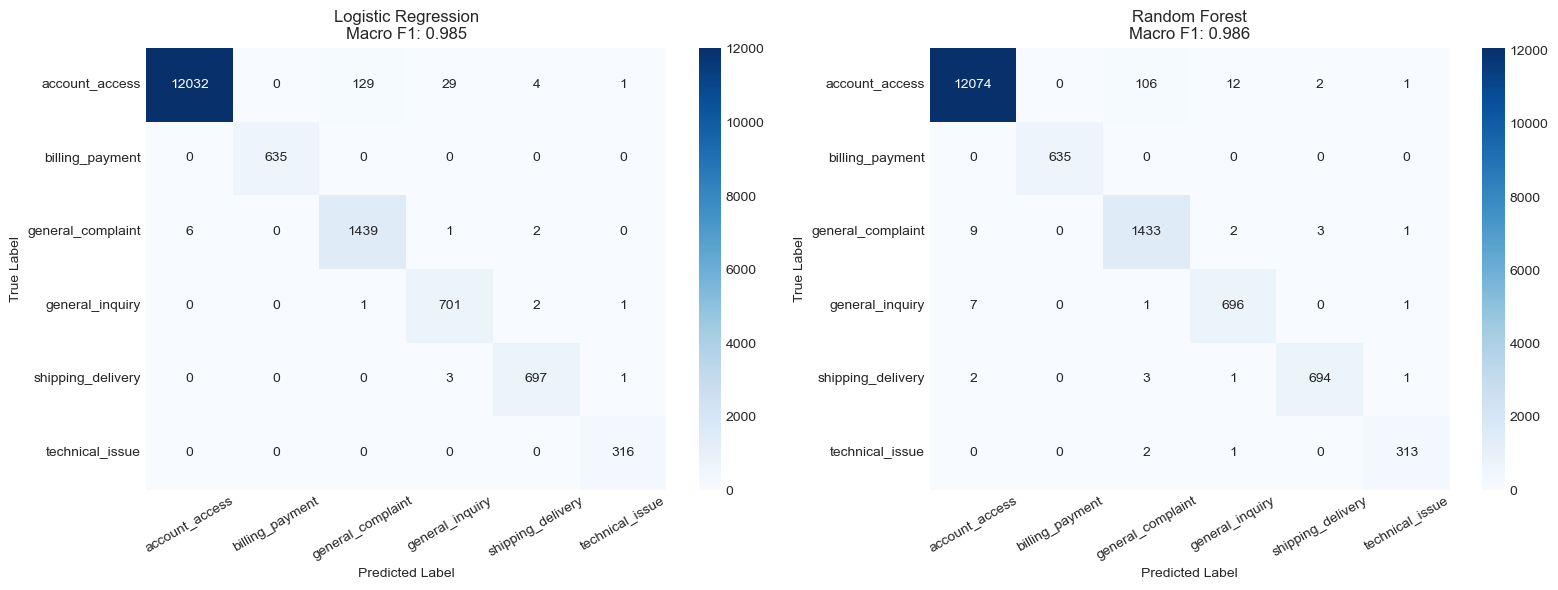

In [8]:
categories = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred, labels=categories)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, ax=ax)
    ax.set_title(f'{title}\nMacro F1: {f1_score(y_test, y_pred, average="macro"):.3f}',
                 fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()

## 8. Baseline Summary Table

In [9]:
results = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Random Forest (TF-IDF)'],
    'Accuracy': [round(lr_acc, 4), round(rf_acc, 4)],
    'Macro F1': [round(lr_f1, 4), round(rf_f1, 4)]
})
print(results.to_string(index=False))
results.to_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/outputs/baseline_results.csv', index=False)
print('\nBaseline benchmark saved to ../outputs/baseline_results.csv')

                       Model  Accuracy  Macro F1
Logistic Regression (TF-IDF)    0.9888    0.9847
      Random Forest (TF-IDF)    0.9903    0.9858

Baseline benchmark saved to ../outputs/baseline_results.csv


## 9. Save Best Baseline Model

In [10]:
# Save the better performing model + vectorizer
best_model = lr if lr_f1 >= rf_f1 else rf
best_name = 'LogisticRegression' if lr_f1 >= rf_f1 else 'RandomForest'

joblib.dump(best_model, f'/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/outputs/baseline_{best_name}.joblib')
joblib.dump(tfidf, '/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/outputs/tfidf_vectorizer.joblib')
print(f'Saved best baseline: {best_name}')
print('BERT needs to beat Macro F1:', round(max(lr_f1, rf_f1), 4))

Saved best baseline: RandomForest
BERT needs to beat Macro F1: 0.9858


## Summary
- Loaded 80,000 labeled tickets (heavily imbalanced: 76% account_access)
- Train/Test split: 64,000 train | 16,000 test (stratified)
- TF-IDF vectorization: 10,000 features, bigrams, sublinear TF scaling
- Applied SMOTE to balance training classes before model fitting
- Trained two baseline classifiers:
    Logistic Regression → Accuracy: 98.88% | Macro F1: 0.9847
    Random Forest       → Accuracy: 99.03% | Macro F1: 0.9858
- Random Forest selected as best baseline — saved to outputs/
- BERT target: Macro F1 > 0.9858
- Next: Notebook 04 — Fine-tune BERT on Google Colab (T4 GPU)